<a href="https://colab.research.google.com/github/prakas0505/Machine_Learning_WithPython/blob/main/ML_with_Python_Day_DBSCAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN Clustering

**DBSCAN** = Density-Based Spatial Clustering of Applications with Noise

### What you'll learn:
1. Why K-Means sometimes fails
2. The 3 types of points in DBSCAN
3. How to build DBSCAN step by step
4. How to use it from scikit-learn

## Step 1 — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN as SklearnDBSCAN

## Step 2 — Create Sample Data

We'll use two datasets:
- **Moons**: two curved clusters (hard for K-Means!)
- **Blobs with noise**: three round clusters plus some random outliers

In [ ]:
np.random.seed(42)

# Dataset 1: Two moon shapes
X_moons, y_moons = make_moons(n_samples=200, noise=0.08, random_state=42)

# Dataset 2: Three blobs + 20 random outliers
X_blobs, y_blobs = make_blobs(n_samples=180,
                               centers=[[-3, -3], [0, 3], [3, -3]],
                               cluster_std=0.5,
                               random_state=42)
noise   = np.random.uniform(-6, 6, size=(20, 2))   # random outlier points
X_noisy = np.vstack([X_blobs, noise])               # combine blobs + noise
y_noisy = np.hstack([y_blobs, np.full(20, -1)])     # label outliers as -1

print("Moons shape :", X_moons.shape)
print("Noisy shape :", X_noisy.shape)

Moons shape : (200, 2)
Noisy shape : (200, 2)


## Step 3 — Visualize Raw Data

Let's see what the data looks like **before** any clustering.

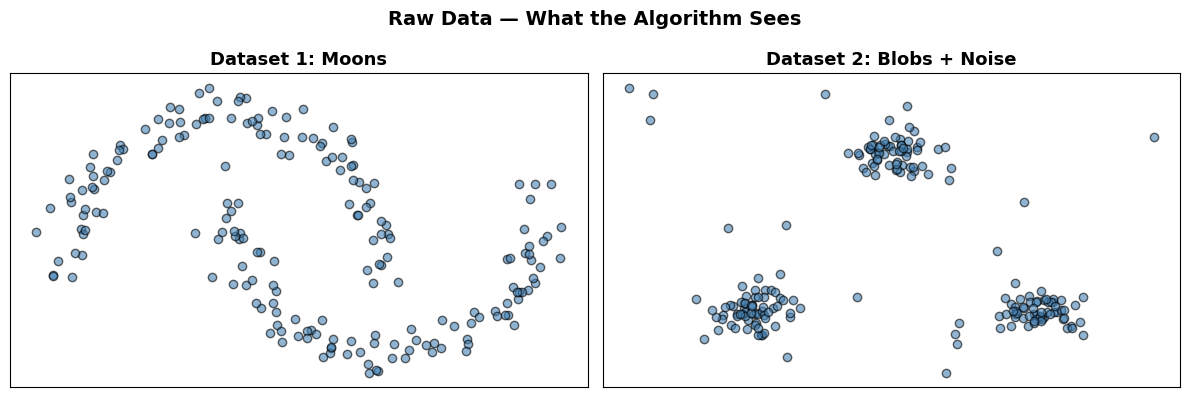

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], color='steelblue', edgecolors='k', alpha=0.6)
axes[0].set_title('Dataset 1: Moons', fontsize=13, fontweight='bold')

axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], color='steelblue', edgecolors='k', alpha=0.6)
axes[1].set_title('Dataset 2: Blobs + Noise', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Raw Data — What the Algorithm Sees', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Why K-Means Fails Here

K-Means assumes clusters are **round/circular**. It draws straight boundaries, so it struggles with curved or oddly-shaped clusters.

/tmp/ipykernel_2052/3670051175.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


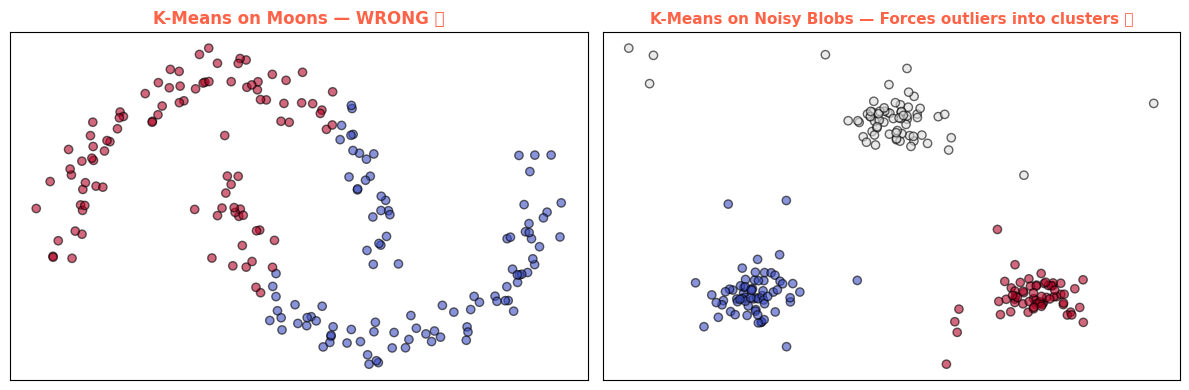

K-Means can't handle curved shapes, and it has no concept of 'noise' or outliers.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# K-Means on Moons
km_moons  = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km_moons.fit_predict(X_moons)

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km,
                cmap='coolwarm', edgecolors='k', alpha=0.6)
axes[0].set_title('K-Means on Moons — WRONG ❌', fontsize=12, fontweight='bold', color='tomato')

# K-Means on Noisy Blobs
km_noisy  = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km_noisy.fit_predict(X_noisy)

axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], c=labels_km,
                cmap='coolwarm', edgecolors='k', alpha=0.6)
axes[1].set_title('K-Means on Noisy Blobs — Forces outliers into clusters ❌',
                  fontsize=11, fontweight='bold', color='tomato')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
print("K-Means can't handle curved shapes, and it has no concept of 'noise' or outliers.")

## Step 5 — DBSCAN Key Concepts

DBSCAN has **2 parameters**:
| Parameter | Meaning |
|---|---|
| `eps` | The radius of a point's neighborhood (how far to look) |
| `min_samples` | Minimum neighbors needed to be a "core" point |

DBSCAN labels every point as one of **3 types**:

| Type | Definition |
|---|---|
| **Core Point** | Has ≥ `min_samples` neighbors within `eps` |
| **Border Point** | Is within `eps` of a core point, but not core itself |
| **Noise Point** | Not close to any core point — it's an outlier! |

**The algorithm in plain English:**
1. Pick any unvisited point
2. Count its neighbors within radius `eps`
3. If enough neighbors → it's a **core point**, start a new cluster
4. Expand the cluster by visiting its neighbors (and their neighbors, etc.)
5. Any point never claimed → labeled as **noise** (-1)
6. Repeat until all points are visited

## Step 6 — Scale the Data

DBSCAN uses distances, so we must scale features to the same range first.

In [ ]:
scaler = StandardScaler()

X_moons_sc = scaler.fit_transform(X_moons)
X_noisy_sc = scaler.fit_transform(X_noisy)

print("Data scaled! Mean ≈ 0, Std ≈ 1 for all features.")

Data scaled! Mean ≈ 0, Std ≈ 1 for all features.


## Step 7 — Build DBSCAN from Scratch

We'll write our own DBSCAN class. Read each method carefully — there are only three!

In [ ]:
class MyDBSCAN:
    """
    A simple DBSCAN implementation using only numpy.

    Parameters:
        eps         : radius of each point's neighborhood
        min_samples : min neighbors needed to be a core point
    """

    def __init__(self, eps=0.5, min_samples=5):
        self.eps         = eps
        self.min_samples = min_samples

    def fit_predict(self, X):
        """Cluster the data and return a label for each point."""
        n            = len(X)
        labels       = np.full(n, -2)   # -2 = not yet visited
        cluster_id   = 0

        for i in range(n):
            if labels[i] != -2:          # already visited, skip
                continue

            neighbors = self._get_neighbors(X, i)

            if len(neighbors) < self.min_samples:
                labels[i] = -1           # too few neighbors → noise
            else:
                # Core point! Grow a cluster from here.
                self._grow_cluster(X, i, neighbors, labels, cluster_id)
                cluster_id += 1

        return labels

    def _get_neighbors(self, X, i):
        """Return indices of all points within eps distance of point i."""
        distances = np.linalg.norm(X - X[i], axis=1)   # distance from point i to all others
        return np.where(distances <= self.eps)[0].tolist()

    def _grow_cluster(self, X, start, neighbors, labels, cluster_id):
        """Expand the cluster by visiting all reachable neighbors."""
        labels[start] = cluster_id
        queue = list(neighbors)   # points to visit next

        while queue:
            j = queue.pop(0)

            if labels[j] == -1:
                labels[j] = cluster_id   # was noise → now a border point

            if labels[j] != -2:          # already processed, skip
                continue

            labels[j]     = cluster_id
            new_neighbors = self._get_neighbors(X, j)

            if len(new_neighbors) >= self.min_samples:
                queue.extend(new_neighbors)   # j is also core → keep expanding

print("MyDBSCAN class is ready!")

MyDBSCAN class is ready!


## Step 8 — Run Our DBSCAN

In [ ]:
# Run on Moons
db_moons      = MyDBSCAN(eps=0.2, min_samples=5)
labels_moons  = db_moons.fit_predict(X_moons_sc)

# Run on Noisy Blobs
db_noisy      = MyDBSCAN(eps=0.3, min_samples=5)
labels_noisy  = db_noisy.fit_predict(X_noisy_sc)

# Quick summary
for name, labels in [('Moons', labels_moons), ('Noisy Blobs', labels_noisy)]:
    n_clusters = len(np.unique(labels[labels >= 0]))
    n_noise    = np.sum(labels == -1)
    print(f"{name}: {n_clusters} clusters found, {n_noise} noise points")

Moons: 9 clusters found, 24 noise points
Noisy Blobs: 3 clusters found, 15 noise points


## Step 9 — Visualize Results

/tmp/ipykernel_2052/3878450080.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


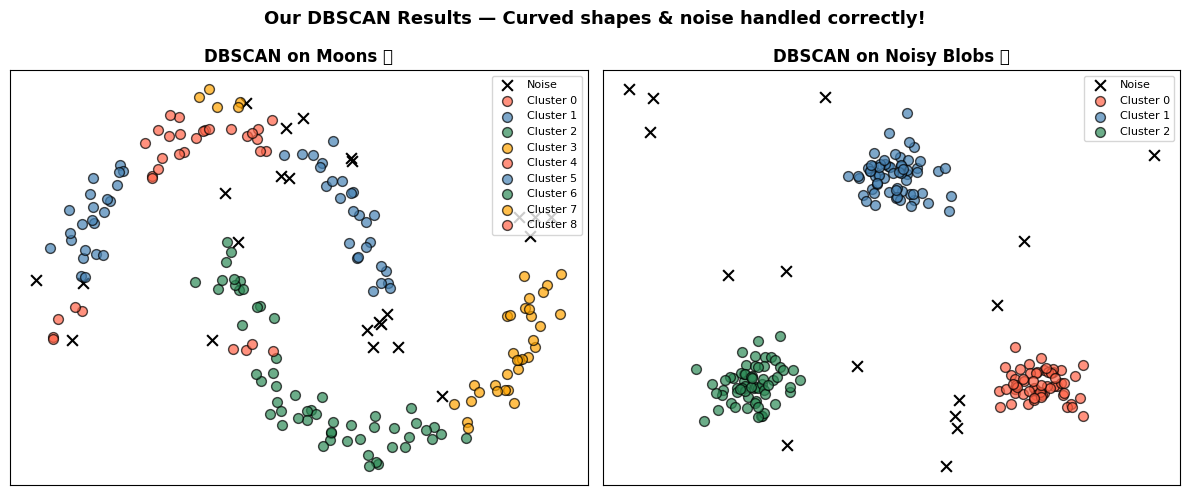

In [ ]:
def plot_dbscan_result(ax, X, labels, title):
    """Helper function to plot DBSCAN output."""
    colors = ['tomato', 'steelblue', 'seagreen', 'orange']

    for label in np.unique(labels):
        mask  = labels == label
        if label == -1:
            # Noise points: black X markers
            ax.scatter(X[mask, 0], X[mask, 1], color='black', marker='x', s=60, label='Noise')
        else:
            # Cluster points: colored circles
            ax.scatter(X[mask, 0], X[mask, 1], color=colors[label % len(colors)],
                       edgecolors='k', alpha=0.7, s=50, label=f'Cluster {label}')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_dbscan_result(axes[0], X_moons_sc,  labels_moons, 'DBSCAN on Moons ✅')
plot_dbscan_result(axes[1], X_noisy_sc,  labels_noisy, 'DBSCAN on Noisy Blobs ✅')

plt.suptitle('Our DBSCAN Results — Curved shapes & noise handled correctly!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10 — How eps Affects Results

Let's see what happens when we change `eps`. This is the most important hyperparameter to tune.

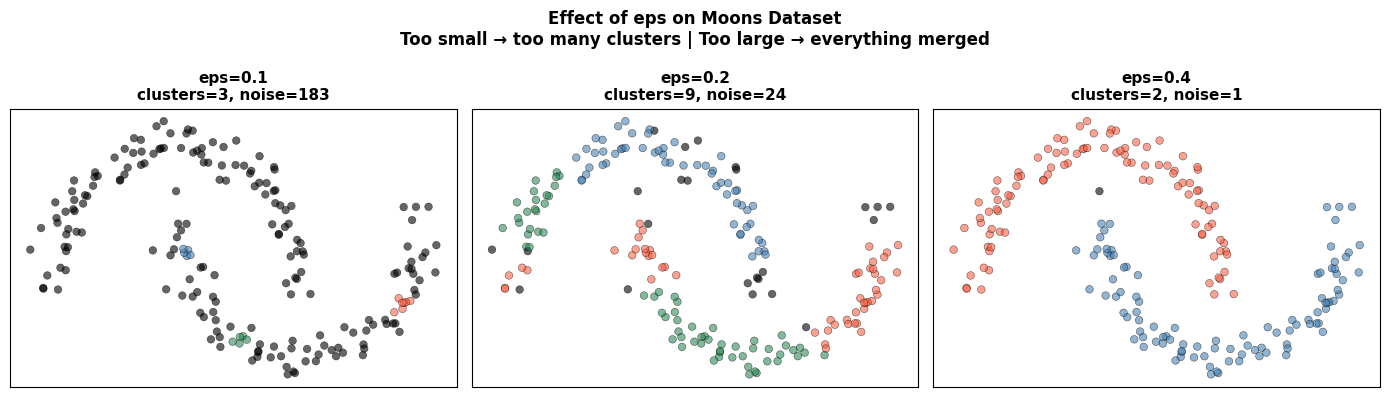

In [ ]:
eps_values = [0.1, 0.2, 0.4]   # small → medium → large

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, eps in zip(axes, eps_values):
    db     = MyDBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_moons_sc)
    n_cl   = len(np.unique(labels[labels >= 0]))
    n_ns   = np.sum(labels == -1)

    colors = ['black' if l == -1 else ['tomato','steelblue','seagreen'][l % 3] for l in labels]
    ax.scatter(X_moons_sc[:, 0], X_moons_sc[:, 1],
               color=colors, edgecolors='k', alpha=0.6, s=30, linewidths=0.4)
    ax.set_title(f'eps={eps}\nclusters={n_cl}, noise={n_ns}', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Effect of eps on Moons Dataset\n'
             'Too small → too many clusters | Too large → everything merged',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11 — Scikit-learn DBSCAN (Production Version)

Our scratch version was for learning. In practice, use scikit-learn's optimized version.

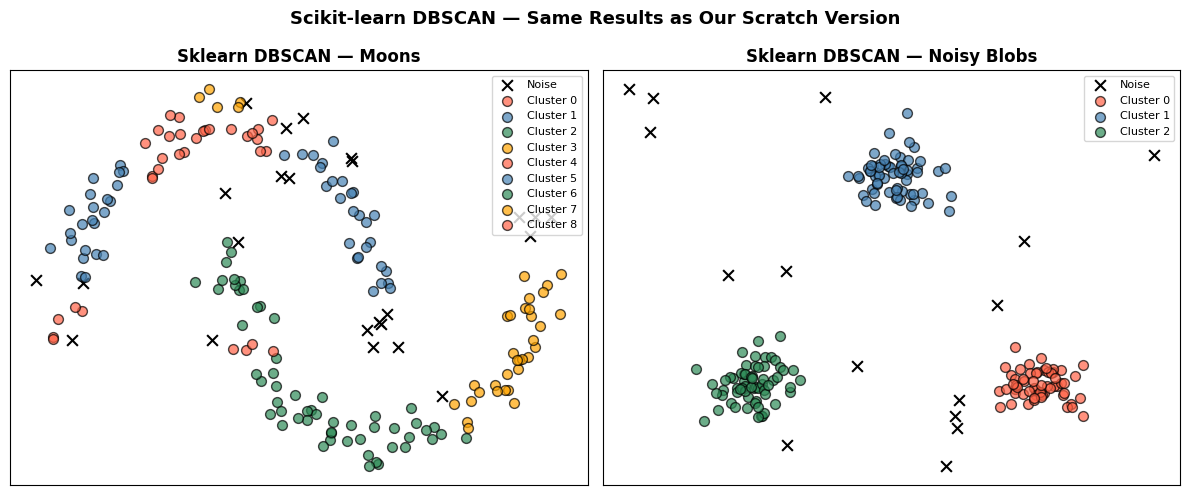

Our scratch labels match sklearn: True


In [ ]:
# Sklearn DBSCAN — same results, much faster on large data
sk_moons = SklearnDBSCAN(eps=0.2, min_samples=5).fit(X_moons_sc)
sk_noisy = SklearnDBSCAN(eps=0.3, min_samples=5).fit(X_noisy_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_result(axes[0], X_moons_sc,  sk_moons.labels_, 'Sklearn DBSCAN — Moons')
plot_dbscan_result(axes[1], X_noisy_sc,  sk_noisy.labels_, 'Sklearn DBSCAN — Noisy Blobs')

plt.suptitle('Scikit-learn DBSCAN — Same Results as Our Scratch Version',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Our scratch labels match sklearn:",
      np.array_equal(labels_moons, sk_moons.labels_))